# Pipeline di validazione — Diagnosi NIA-AA a tre assi

Notebook di validazione locale: esegue la pipeline di calcolo diagnosi sul dataset reale "di punta" (FreeSurfer 4.3, CSF Elecsys, PET FBP) e ispeziona i risultati. **Non salva/carica nulla sul Datalake** — è solo un controllo di sanità prima di un uso più esteso.

## Le tre diagnosi NIA-AA calcolate

Il package `rules` calcola tre diagnosi indipendenti a partire dagli stessi dati di visita:

1. **DX1 — Diagnosi clinica** (`dx1_nia_clinical.py`, NIA-AA 2011 / McKhann-Albert-Sperling): CN / MCI / Dementia da CDR, MMSE, test di memoria, FAQ. Non guarda mai i biomarcatori.
2. **DX2 — Diagnosi biologica ATN** (`dx2_nia_atn.py`, NIA-AA 2018 / Jack et al.): stato Amiloide (A) / Tau (T) / Neurodegenerazione (N) da CSF, PET, volumi FreeSurfer. Non guarda mai la diagnosi clinica.
3. **DX3 — Staging combinato** (`dx3_nia_combined.py`, NIA-AA 2024 / Jack et al.): combina DX1 + DX2 (+ severità CDR-SB) in uno stadio 1-6 (dal preclinico all'AD conclamato), senza mai sovrascrivere gli assi 1 e 2.

Le tre diagnosi sono indipendenti per design: DX1 e DX2 non si condizionano a vicenda; DX3 le combina solo *dopo* che sono già state calcolate entrambe.

Ordine di esecuzione: `assign_dx1_batch` → `assign_dx2_batch` → `assign_dx3_batch` (i primi due sono in realtà indipendenti tra loro — solo il terzo richiede che i precedenti siano già stati calcolati).

In [1]:
import sys, os

# Il notebook vive dentro rules/, ma il package `rules` va importato come se
# ci si trovasse in DX_calculators/ (vedi README.md, sezione "Uso").
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

import pandas as pd
from dl_client import DatalakeClient
from rules import assign_dx1_batch, assign_dx2_batch, assign_dx3_batch
from rules.config import FLAG_JOIN_SEP

client = DatalakeClient()

In [2]:
# Dataset "di punta": FreeSurfer 4.3, CSF Elecsys, PET FBP — combinazione dichiarata
# "current focus dataset" in config.py (CSF_CUTOFFS["ELECSYS"], AMYLOID_PET_CUTOFFS["FBP"]).
# Elenco file disponibili verificato in prove.ipynb (cella di query_files).
OBJECT_NAME = "cleaned/merged/combination/merge_FSVERSION_4-3_METHOD_CSF_elecsys_METHOD_PET_FBP.csv"
BUCKET = "aind"

df = client.download_file(object_name=OBJECT_NAME, bucket=BUCKET)
print(df.shape)
df.head()

(17599, 72)


c:\users\chiarapollicini\onedrive - net service s.p.a\documenti\github\aind\wp-2\dl_client\dl_client\client.py:557: DtypeWarning: Columns (5,15,27,54,55,56) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(io.BytesIO(content), delimiter=delimiter)


,RID,COHORT,VISCODE,VISIT_MONTH,EXAMDATE,FLDSTRENG,FSVERSION,IMAGEUID,update_stamp,Ventricles%ICV,...,MARRY/divorced,MARRY/married,MARRY/single,MARRY/widowed,RACE/Asian,RACE/Black,RACE/Mixed,RACE/Native_american,RACE/White,Tprofile
0,1.0,ADNI1,f,0.0,2005-08-18,NaN,NaN,NaN,2024-08-22 07:18:34.0,NaN,...,0,True,0,0,0.0,0.0,0.0,0.0,0.0,NaN
1,2.0,ADNI1,bl,0.0,2005-09-08,1.5T,4.3,35475.0,2023-07-07 04:59:40.0,5.957343,...,0,True,0,0,0.0,0.0,1.0,0.0,0.0,NaN
2,2.0,ADNI1,m06,6.0,2006-03-06,NaN,NaN,NaN,2024-08-22 07:18:34.0,NaN,...,0,True,0,0,0.0,0.0,1.0,0.0,0.0,NaN
3,2.0,ADNI1,m36,36.0,2008-08-27,NaN,NaN,NaN,2024-08-22 07:18:34.0,NaN,...,0,True,0,0,0.0,0.0,1.0,0.0,0.0,NaN
4,2.0,ADNIGO,m60,60.0,2010-09-22,NaN,NaN,NaN,2025-05-15 17:03:57.0,NaN,...,True,0,0,0,0.0,0.0,1.0,0.0,0.0,NaN


In [3]:
meta = client.get_metadata(object_name=OBJECT_NAME, bucket=BUCKET)
metadata_custom = meta["metadata"]["custom"]

# Attesi: elecsys / FBP / 4.3 — conferma che il file caricato è davvero quello giusto.
print("CSF_filter:", metadata_custom.get("CSF_filter"))
print("PET_filter:", metadata_custom.get("PET_filter"))
print("VOLUMES_filter:", metadata_custom.get("VOLUMES_filter"))

CSF_filter: elecsys
PET_filter: FBP
VOLUMES_filter: 4.3


## Nota: DX1 non dipende più dal protocollo ADNI (risolto)

**Aggiornamento**: `DX1_clinical` non risolve più nessun protocollo/fase ADNI. In una versione precedente di questo notebook, `classify_syndromic()` selezionava i cutoff clinici (memoria, MMSE) in base a `ORIGPROT` (fase di arruolamento), col rischio di dipendere da una colonna che si credeva assente dal dataset di merge finale. Verificando i dati reali scaricati sopra, la colonna `COHORT` (con valori tipo `ADNI1`, `ADNIGO`) **è in realtà presente** — quindi quell'assunzione era imprecisa — ma la questione è comunque diventata non rilevante: la ricerca in letteratura ha confermato che i criteri NIA-AA 2011 (Albert et al. 2011) definiscono l'impairment di memoria come soglia statistica generica ("1-1.5 SD sotto la norma età/educazione"), non un cutoff legato a una fase di studio specifica. `dx1_nia_clinical.py` ora usa un riferimento unico (`config.MEMORY_IMPAIRMENT_CUTOFFS`, `config.MMSE_GATES`), indipendente da qualunque colonna di protocollo/coorte — nessuna colonna `ORIGPROT`/`COHORT` viene più letta da DX1.

**Nota**: questa soglia unica resta provvisoria — i numeri usati sono ancora quelli del cohort ADNI3/4 (Aisen et al. 2024), non una tabella normativa NIA-AA indipendente da ADNI. Un raffinamento futuro (norme età-corrette indipendenti, es. MOANS/Mayo/Schmidt) resta possibile — vedi `README.md`, sezione "Stato/TODO noti".

In [ ]:
# Nessuna colonna DX1_protocol_used da verificare: DX1 non risolve più alcun
# protocollo/fase (resolve_protocol() rimosso — vedi nota sopra).
df = assign_dx1_batch(df)

In [5]:
df = assign_dx2_batch(df, metadata=metadata_custom)
df[["DX2_A", "DX2_T", "DX2_N"]].isna().sum()

DX2_A    12566
DX2_T    12682
DX2_N    11646
dtype: int64

In [6]:
df = assign_dx3_batch(df)
df["DX3_stage"].value_counts(dropna=False)

DX3_stage
NaN    15820
1.0      461
4.0      436
5.0      382
3.0      308
2.0      116
6.0       76
Name: count, dtype: int64

In [7]:
df["DX1_clinical"].value_counts(dropna=False)

DX1_clinical
MCI         6694
CN          5424
Dementia    3637
Unknown     1844
Name: count, dtype: int64

In [8]:
df["DX2_ATN_label"].value_counts(dropna=False)

DX2_ATN_label
A?        12566
A-         2441
A+T-N-      659
A+T+N+      589
A+T-        570
A+T-N+      361
A+T+N-      209
A+T+        132
A+T?         52
A+T?N-       14
A+T?N+        6
Name: count, dtype: int64

In [9]:
df[["DX3_stage", "DX3_label"]].value_counts(dropna=False)

DX3_stage  DX3_label           
NaN        NaN                     15820
1.0        Preclinical AD            461
4.0        Mild AD dementia          436
5.0        Moderate AD dementia      382
3.0        Prodromal AD              308
2.0        Preclinical AD + tau      116
6.0        Severe AD dementia         76
Name: count, dtype: int64

In [10]:
def flag_counts(series: pd.Series) -> pd.Series:
    """Frequenza dei singoli flag (non delle combinazioni) in una colonna *_flags."""
    return series.dropna().str.split(FLAG_JOIN_SEP).explode().value_counts()

flag_counts(df["DX1_flags"])

DX1_flags
MISSING_LDELTOTAL                   17599
MISSING_CDMEMORY                    15755
CDGLOBAL_DERIVED_FROM_CDRSB         12568
MEMORY_FALLBACK_RAVLT               11273
MISSING_MEMORY_TEST                  6326
TIE_CDR_HIGH_NO_FUNC_IMPAIRMENT      2137
TIE_FAQ_MISSING                      2079
MISSING_CDGLOBAL                     1844
ASSUMED_EDUC_BAND                    1488
TIE_CDR0_MEM_IMPAIRED                1118
MISSING_MMSE_GATE_SKIPPED             634
TIE_MMSE_BELOW_AD_GATE_WITH_CDR0        1
Name: count, dtype: int64

In [11]:
# Atteso: FS_VERSION_CUTOFF_PROXY_FROM_5.1 su tutte le righe con volume disponibile
# (dataset FS4.3, proxy dei cutoff 5.1 — vedi config.NEUROIMAGING_CUTOFFS["pct_icv"]["4.3"]).
# FS_VERSION_CUTOFFS_UNCONFIRMED non dovrebbe comparire più per nessuna versione nota.
flag_counts(df["DX2_flags"])

DX2_flags
METHOD_FROM_METADATA                52797
NO_BIOMARKERS                        9909
PARTIAL_ATN                          4422
FS_VERSION_CUTOFF_PROXY_FROM_5.1     3532
CONFLICTING_AMYLOID_PET_CSF           276
Name: count, dtype: int64

In [12]:
# Controllo di sanità: per costruzione di combine_stage(), stage 1-2 devono venire
# solo da DX1_clinical=CN, stage 3 solo da MCI, stage 4-6 solo da Dementia.
# Qualunque cella fuori da questo pattern segnala un bug da investigare.
pd.crosstab(df["DX1_clinical"], df["DX3_stage"], dropna=False)

DX3_stage,1.0,2.0,3.0,4.0,5.0,6.0,NaN
DX1_clinical,,,,,,,
CN,461,116,0,0,0,0,4847
Dementia,0,0,0,436,382,76,2743
MCI,0,0,308,0,0,0,6386
Unknown,0,0,0,0,0,0,1844


## Confronto con la diagnosi originale del dataset (DX/CN, DX/MCI, DX/Dementia)

Il dataset porta anche una diagnosi originale, già presente prima di questo calcolo (colonne dummy `DX/CN`, `DX/MCI`, `DX/Dementia`). La confrontiamo qui con `DX1_clinical` (asse clinico, stesso vocabolario CN/MCI/Dementia — ci aspettiamo accordo alto) e con `DX3_stage` (staging combinato NIA-AA 2024 — vocabolario diverso, più granulare: non ci aspettiamo un accordo diretto, ma una relazione plausibile, cioè stadi più avanzati concentrati nei casi clinicamente più compromessi).

In [13]:
# Riusa dummies_to_categorical (già usata in WP-2/Data_cleaning/post-generation/
# reverse_transformations.py) invece di reinventare la ricostruzione da dummy.
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../../WP-2/Data_cleaning/post-generation")))
from dummy_to_categorical import dummies_to_categorical

# drop_dummies=False: le colonne DX/CN, DX/MCI, DX/Dementia restano nel DataFrame.
# handle_all_zero="none": righe senza nessun dummy a 1 diventano "Unknown" (stesso
# vocabolario di DX_LABELS["UNKNOWN"] in config.py), invece di NaN silenzioso.
df = dummies_to_categorical(
    df, dummy_prefix="DX", separator="/", drop_dummies=False,
    handle_all_zero="none", original_column_name="DX_original",
)
df["DX_original"].value_counts(dropna=False)

DX_original
CN          9264
MCI         5082
Dementia    2472
Unknown      781
Name: count, dtype: int64

In [14]:
crosstab_dx1 = pd.crosstab(df["DX_original"], df["DX1_clinical"], dropna=False)
crosstab_dx1

DX1_clinical,CN,Dementia,MCI,Unknown
DX_original,,,,
CN,4798,330,2527,1609
Dementia,3,2190,227,52
MCI,260,1092,3579,151
Unknown,363,25,361,32


In [ ]:
import matplotlib.pyplot as plt

def bubble_scatter(crosstab: pd.DataFrame, title: str) -> None:
    """Scatter delle celle di un crosstab: un punto per combinazione osservata,
    con dimensione proporzionale al conteggio (etichettato sopra il punto).

    NaN su indice/colonne (es. DX3_stage/DX3_label=None per le righe non
    stadiate) vengono sostituiti con "N/D" prima di procedere: un vero NaN in
    crosstab.columns fa fallire DataFrame.stack() su alcune versioni di pandas
    ("Columns with duplicate values are not supported in stack"), o produce un
    NaN in `pairs` che poi rompe list.index(nan) più sotto ("nan is not in
    list") su altre versioni — safe in entrambi i casi."""
    crosstab = crosstab.copy()
    crosstab.index = crosstab.index.fillna("N/D")
    crosstab.columns = crosstab.columns.fillna("N/D")

    x_categories = list(crosstab.columns)
    y_categories = list(crosstab.index)
    pairs = crosstab.stack().reset_index()
    pairs.columns = ["original", "computed", "count"]
    pairs = pairs[pairs["count"] > 0]

    x_pos = pairs["computed"].map({c: i for i, c in enumerate(x_categories)})
    y_pos = pairs["original"].map({c: i for i, c in enumerate(y_categories)})

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(x_pos, y_pos, s=pairs["count"] * 3, alpha=0.6, edgecolors="black")
    for _, row in pairs.iterrows():
        ax.annotate(
            str(row["count"]),
            (x_categories.index(row["computed"]), y_categories.index(row["original"])),
            ha="center", va="center", fontsize=8,
        )
    ax.set_xticks(range(len(x_categories)))
    ax.set_xticklabels(x_categories, rotation=45, ha="right")
    ax.set_yticks(range(len(y_categories)))
    ax.set_yticklabels(y_categories)
    ax.set_xlabel("Diagnosi calcolata")
    ax.set_ylabel("Diagnosi originale (dataset)")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()

bubble_scatter(crosstab_dx1, "DX1_clinical vs diagnosi originale (dimensione punto = n. righe)")

In [16]:
crosstab_dx3 = pd.crosstab(df["DX_original"], df["DX3_stage"], dropna=False)
crosstab_dx3

DX3_stage,1.0,2.0,3.0,4.0,5.0,6.0,NaN
DX_original,,,,,,,
CN,432,110,39,14,9,2,8658
Dementia,0,0,34,181,354,73,1830
MCI,24,6,235,236,16,1,4564
Unknown,5,0,0,5,3,0,768


ValueError: nan is not in list

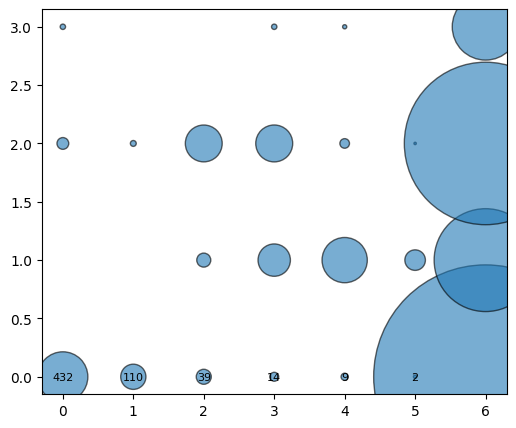

In [18]:
bubble_scatter(crosstab_dx3, "DX3_stage vs diagnosi originale (dimensione punto = n. righe)")

## Riepilogo

- Nessun salvataggio o upload al Datalake eseguito in questo notebook.
- Annotare qui eventuali anomalie osservate nelle distribuzioni o nel cross-tab sopra.
- Confronto con la diagnosi originale (sezione sopra): annotare qui il livello di accordo osservato tra `DX1_clinical`/`DX3_stage` e `DX_original` — un forte disaccordo su DX1 (stesso vocabolario CN/MCI/Dementia) è un segnale da investigare, un disaccordo parziale su DX3 (staging biologico-clinico più granulare) è atteso.
- Follow-up rimasto (non affrontato qui): derivazione empirica di cutoff volumetrici FS-version-specifici — oggi tutte le versioni non-5.1 usano un proxy dei cutoff 5.1 (flag `FS_VERSION_CUTOFF_PROXY_FROM_5.1`), non cutoff validati indipendentemente. (Il follow-up sull'indipendenza di DX1 dal protocollo ADNI è stato completato in questa sessione — vedi la nota sopra.)